# LSTM Model for Text Classification

This notebook handles the entire pipeline for training an LSTM model on text data:
1. Data loading and preprocessing
2. Text tokenization and sequence creation
3. Word embeddings
4. Hyperparameter tuning
5. Model training and evaluation
6. Model saving


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re
import string
import nltk
from nltk.tokenize import word_tokenize
import keras_tuner as kt
import os

nltk.download('punkt', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


## Data Preparation

In [13]:
print("Loading dataset...")
df = pd.read_csv("../../datasets/custom_dataset.csv", sep="\t")
print(f"Dataset shape: {df.shape}")
df.head()


Loading dataset...
Dataset shape: (5437, 2)


,Text,Label
0,"In mechanics, a variable-mass system is a coll...",Human
1,Variable-mass systems in fluids involve object...,AI
2,"Geomechanics (from the Greek γεός, i.e. prefix...",Human
3,Geomechanics studies the mechanical behavior o...,AI
4,Microscale chemistry (often referred to as sma...,Human


In [14]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

df[['Text', 'cleaned_text']].sample(5)

labels = df['Label'].apply(lambda x: 0 if x == 'Human' else 1).values

print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['cleaned_text'].values, labels, test_size=0.3, random_state=2025, stratify=labels
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=2025, stratify=temp_labels
)

print(f"Training set: {len(train_texts)} samples")
print(f"Validation set: {len(val_texts)} samples")
print(f"Test set: {len(test_texts)} samples")


Label distribution: {1: 3461, 0: 1976}
Training set: 3805 samples
Validation set: 816 samples
Test set: 816 samples


In [15]:

max_words = 2500
max_seq_length = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_seq_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_length, padding='post', truncating='post')

print(f"Training sequences shape: {train_padded.shape}")
print(f"Validation sequences shape: {val_padded.shape}")
print(f"Test sequences shape: {test_padded.shape}")


Vocabulary size: 2500
Training sequences shape: (3805, 128)
Validation sequences shape: (816, 128)
Test sequences shape: (816, 128)


## Model Development

In [16]:
def build_lstm_model(hp):
    model = keras.Sequential()
    
    embedding_dim = hp.Int('embedding_dim', 64, 256, step=32)
    model.add(layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_seq_length,
        embeddings_initializer=initializers.GlorotUniform(seed=2025)
    ))
    
    model.add(layers.SpatialDropout1D(
        hp.Float('spatial_dropout', 0.1, 0.5, step=0.1)
    ))
    
    model.add(layers.LSTM(
        units=hp.Int('lstm_units_1', 8, 64, step=8),
        return_sequences=True,
        dropout=hp.Float('dropout_1', 0.1, 0.5, step=0.1),
        recurrent_dropout=hp.Float('recurrent_dropout_1', 0.1, 0.5, step=0.1),
        activation='tanh'
    ))
    
    model.add(layers.LSTM(
        units=hp.Int('lstm_units_2', 8, 64, step=8),
        dropout=hp.Float('dropout_2', 0.1, 0.5, step=0.1),
        recurrent_dropout=hp.Float('recurrent_dropout_2', 0.1, 0.5, step=0.1),
        activation='tanh'
    ))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model

tuner = kt.Hyperband(
    build_lstm_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='../../tuner_results',
    project_name='lstm_model'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

tuner.search(
    train_padded, train_labels,
    epochs=25,
    validation_data=(val_padded, val_labels),
    callbacks=[early_stopping]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters: {best_hps.values}")


Trial 30 Complete [00h 02m 29s]
val_accuracy: 0.9767156839370728

Best val_accuracy So Far: 0.9877451062202454
Total elapsed time: 00h 35m 38s
Best hyperparameters: {'embedding_dim': 64, 'spatial_dropout': 0.2, 'lstm_units_1': 40, 'dropout_1': 0.5, 'recurrent_dropout_1': 0.2, 'lstm_units_2': 64, 'dropout_2': 0.2, 'recurrent_dropout_2': 0.4, 'learning_rate': 0.00038019530197062906, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0023'}


Epoch 1/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.6201 - auc_3: 0.4904 - loss: 0.6697 - precision_3: 0.6324 - recall_3: 0.9631

119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 197ms/step - accuracy: 0.6202 - auc_3: 0.4906 - loss: 0.6696 - precision_3: 0.6325 - recall_3: 0.9633 - val_accuracy: 0.6373 - val_auc_3: 0.5380 - val_loss: 0.6545 - val_precision_3: 0.6373 - val_recall_3: 1.0000 - learning_rate: 3.8020e-04
Epoch 2/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6379 - auc_3: 0.5215 - loss: 0.6542 - precision_3: 0.6376 - recall_3: 0.9988

119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 187ms/step - accuracy: 0.6380 - auc_3: 0.5221 - loss: 0.6540 - precision_3: 0.6377 - recall_3: 0.9986 - val_accuracy: 0.8811 - val_auc_3: 0.9454 - val_loss: 0.3719 - val_precision_3: 0.9256 - val_recall_3: 0.8846 - learning_rate: 3.8020e-04
Epoch 3/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8820 - auc_3: 0.9209 - loss: 0.3324 - precision_3: 0.9062 - recall_3: 0.9094

119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step - accuracy: 0.8822 - auc_3: 0.9211 - loss: 0.3319 - precision_3: 0.9063 - recall_3: 0.9095 - val_accuracy: 0.9608 - val_auc_3: 0.9847 - val_loss: 0.1519 - val_precision_3: 0.9519 - val_recall_3: 0.9885 - learning_rate: 3.8020e-04
Epoch 4/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9381 - auc_3: 0.9695 - loss: 0.1899 - precision_3: 0.9585 - recall_3: 0.9438

119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 185ms/step - accuracy: 0.9382 - auc_3: 0.9696 - loss: 0.1897 - precision_3: 0.9586 - recall_3: 0.9440 - val_accuracy: 0.9743 - val_auc_3: 0.9900 - val_loss: 0.0923 - val_precision_3: 0.9807 - val_recall_3: 0.9788 - learning_rate: 3.8020e-04
Epoch 5/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9627 - auc_3: 0.9837 - loss: 0.1292 - precision_3: 0.9771 - recall_3: 0.9640

...

119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 186ms/step - accuracy: 0.9770 - auc_3: 0.9899 - loss: 0.0879 - precision_3: 0.9881 - recall_3: 0.9757 - val_accuracy: 0.9853 - val_auc_3: 0.9917 - val_loss: 0.0692 - val_precision_3: 0.9829 - val_recall_3: 0.9942 - learning_rate: 3.8020e-04
Epoch 7/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9825 - auc_3: 0.9940 - loss: 0.0643 - precision_3: 0.9844 - recall_3: 0.9881

119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 183ms/step - accuracy: 0.9825 - auc_3: 0.9940 - loss: 0.0643 - precision_3: 0.9845 - recall_3: 0.9881 - val_accuracy: 0.9865 - val_auc_3: 0.9914 - val_loss: 0.0660 - val_precision_3: 0.9848 - val_recall_3: 0.9942 - learning_rate: 3.8020e-04
Epoch 8/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 190ms/step - accuracy: 0.9912 - auc_3: 0.9976 - loss: 0.0395 - precision_3: 0.9927 - recall_3: 0.9934 - val_accuracy: 0.9853 - val_auc_3: 0.9895 - val_loss: 0.0751 - val_precision_3: 0.9847 - val_recall_3: 0.9923 - learning_rate: 3.8020e-04
Epoch 9/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.9879 - auc_3: 0.9963 - loss: 0.0486 - precision_3: 0.9901 - recall_3: 0.9909 - val_accuracy: 0.9853 - val_auc_3: 0.9918 - val_loss: 0.0669 - val_precision_3: 0.9811 - val_recall_3: 0.9962 - learning_rate: 3.8020e-04
Epoch 10/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9932 - auc_3: 0.9968 - loss: 0.0326 - precision_3: 0.9930 - recall_3: 0.9962

119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.9932 - auc_3: 0.9968 - loss: 0.0326 - precision_3: 0.9930 - recall_3: 0.9962 - val_accuracy: 0.9877 - val_auc_3: 0.9944 - val_loss: 0.0565 - val_precision_3: 0.9885 - val_recall_3: 0.9923 - learning_rate: 1.9010e-04
Epoch 11/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 190ms/step - accuracy: 0.9935 - auc_3: 0.9991 - loss: 0.0245 - precision_3: 0.9957 - recall_3: 0.9941 - val_accuracy: 0.9877 - val_auc_3: 0.9938 - val_loss: 0.0605 - val_precision_3: 0.9885 - val_recall_3: 0.9923 - learning_rate: 1.9010e-04
Epoch 12/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9929 - auc_3: 0.9984 - loss: 0.0308 - precision_3: 0.9958 - recall_3: 0.9930

119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 193ms/step - accuracy: 0.9929 - auc_3: 0.9984 - loss: 0.0308 - precision_3: 0.9958 - recall_3: 0.9930 - val_accuracy: 0.9865 - val_auc_3: 0.9933 - val_loss: 0.0562 - val_precision_3: 0.9829 - val_recall_3: 0.9962 - learning_rate: 1.9010e-04
Epoch 13/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9930 - auc_3: 0.9972 - loss: 0.0315 - precision_3: 0.9949 - recall_3: 0.9941

119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.9930 - auc_3: 0.9972 - loss: 0.0316 - precision_3: 0.9949 - recall_3: 0.9941 - val_accuracy: 0.9902 - val_auc_3: 0.9932 - val_loss: 0.0533 - val_precision_3: 0.9923 - val_recall_3: 0.9923 - learning_rate: 1.9010e-04
Epoch 14/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step - accuracy: 0.9947 - auc_3: 0.9985 - loss: 0.0231 - precision_3: 0.9972 - recall_3: 0.9945 - val_accuracy: 0.9865 - val_auc_3: 0.9917 - val_loss: 0.0606 - val_precision_3: 0.9829 - val_recall_3: 0.9962 - learning_rate: 1.9010e-04
Epoch 15/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step - accuracy: 0.9960 - auc_3: 0.9996 - loss: 0.0172 - precision_3: 0.9974 - recall_3: 0.9964 - val_accuracy: 0.9877 - val_auc_3: 0.9898 - val_loss: 0.0649 - val_precision_3: 0.9885 - val_recall_3: 0.9923 - learning_rate: 1.9010e-04
Epoch 16/25
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.9947 - auc_3: 0.9990 - loss: 0.0212 - precision_3: 0.9974 - recall_3: 0.9942 - val_a

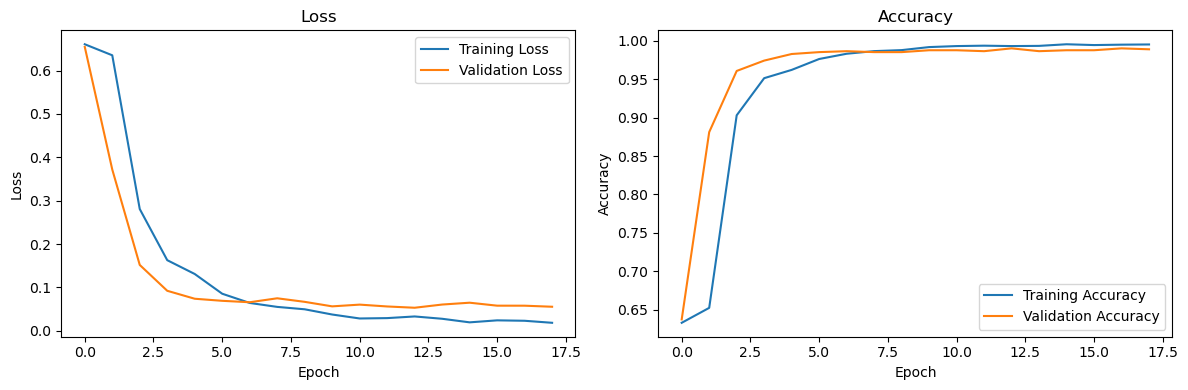

In [ ]:
model = tuner.hypermodel.build(best_hps)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('../../trained_models/tensorflowlstm_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    train_padded, train_labels,
    validation_data=(val_padded, val_labels),
    epochs=25,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Model Evaluation

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9857 - auc_3: 0.9933 - loss: 0.0626 - precision_3: 0.9887 - recall_3: 0.9887
Test accuracy: 0.9914
Test AUC: 0.9960
Test precision: 0.9923
Test recall: 0.9942
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step


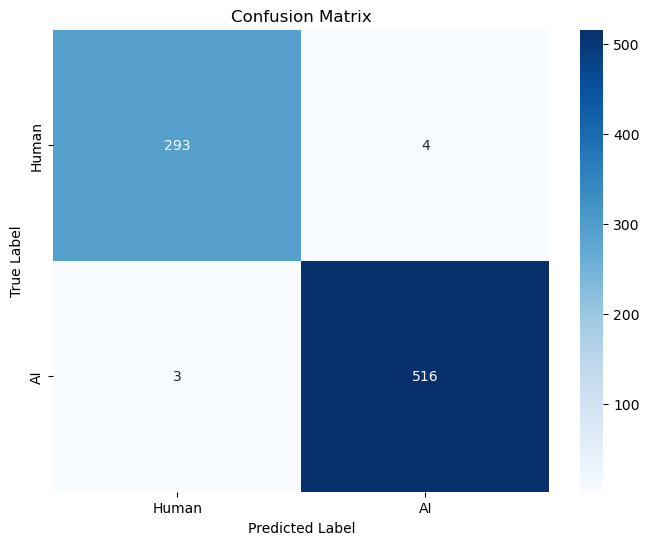

Classification Report:
              precision    recall  f1-score   support

       Human       0.99      0.99      0.99       297
          AI       0.99      0.99      0.99       519

    accuracy                           0.99       816
   macro avg       0.99      0.99      0.99       816
weighted avg       0.99      0.99      0.99       816



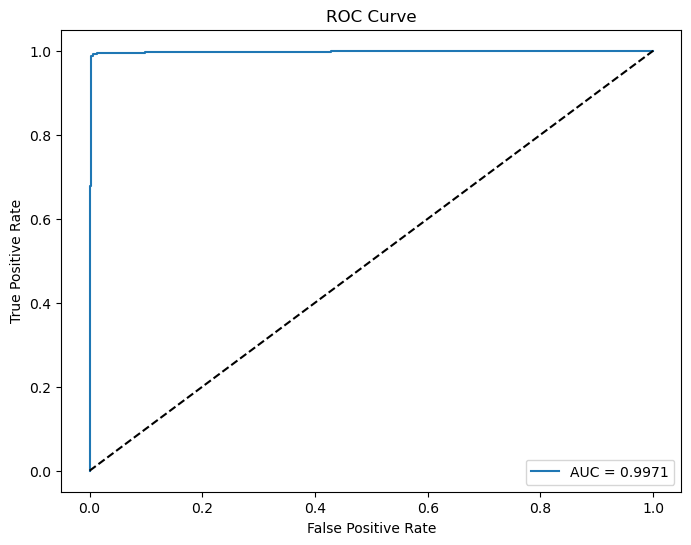

In [19]:
model = keras.models.load_model('../../trained_models/tensorflow/lstm_model.h5')

test_loss, test_acc, test_auc, test_precision, test_recall = model.evaluate(test_padded, test_labels)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")

y_pred_prob = model.predict(test_padded)
y_pred = (y_pred_prob > 0.5).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Classification Report:")
print(classification_report(test_labels, y_pred, target_names=['Human', 'AI']))

fpr, tpr, _ = roc_curve(test_labels, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


## Model Deployment

In [ ]:
model.save('../../trained_models/tensorflow/lstm_model.h5')
print("Model saved to '../../trained_models/tensorflow/lstm_model.h5'")

import pickle

with open('../../trained_models/tensorflow/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump({
        'tokenizer': tokenizer,
        'max_seq_length': max_seq_length,
        'clean_text': clean_text
    }, f)
print("Tokenizer saved to '../../trained_models/tensorflow/lstm_tokenizer.pkl'")

def predict_text(text, model, preprocessor):
    cleaned_text = preprocessor['clean_text'](text)
    
    sequence = preprocessor['tokenizer'].texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
    
    prediction = model.predict(padded)[0][0]
    
    return {
        'probability': float(prediction),
        'prediction': 'AI' if prediction > 0.5 else 'Human'
    }

loaded_model = keras.models.load_model('../../trained_models/tensorflow/lstm_model.h5')
with open('../../trained_models/tensorflow/lstm_tokenizer.pkl', 'rb') as f:
    loaded_preprocessor = pickle.load(f)

sample_text = "This is a sample text to test the model."
result = predict_text(sample_text, loaded_model, loaded_preprocessor)
print(f"Sample text: '{sample_text}'")
print(f"Prediction: {result['prediction']}")


Model saved to '../../trained_models/tensorflow/lstm_model.h5'
Tokenizer saved to '../../trained_models/tensorflow/lstm_tokenizer.pkl'
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
Sample text: 'This is a sample text to test the model.'
Prediction: Human (Probability: 0.0038)
